In [6]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import vis_tools as vis

In [11]:
# ------------------------------------------------------------------------------ #
# Save

files = sorted(Path("data/prices/").glob("*.csv"))

# Stack all rows from all days
raw = pd.concat((pd.read_csv(f, sep=";") for f in files), ignore_index=True)

# Build panel
mid_df = raw.pivot(
    index=["day", "timestamp"], columns="product", values="mid_price"
).sort_index()
mid_df.columns.name = None
log_diff_df = 100 * np.log(mid_df).diff().iloc[1:]

# ------------------------------------------------------------------------------- #
# Build bid panel
bid_df = raw.pivot(
    index=["day", "timestamp"], columns="product", values="bid_price_1"
).sort_index()
bid_df.columns.name = None

# Build ask panel
ask_df = raw.pivot(
    index=["day", "timestamp"], columns="product", values="ask_price_1"
).sort_index()
ask_df.columns.name = None


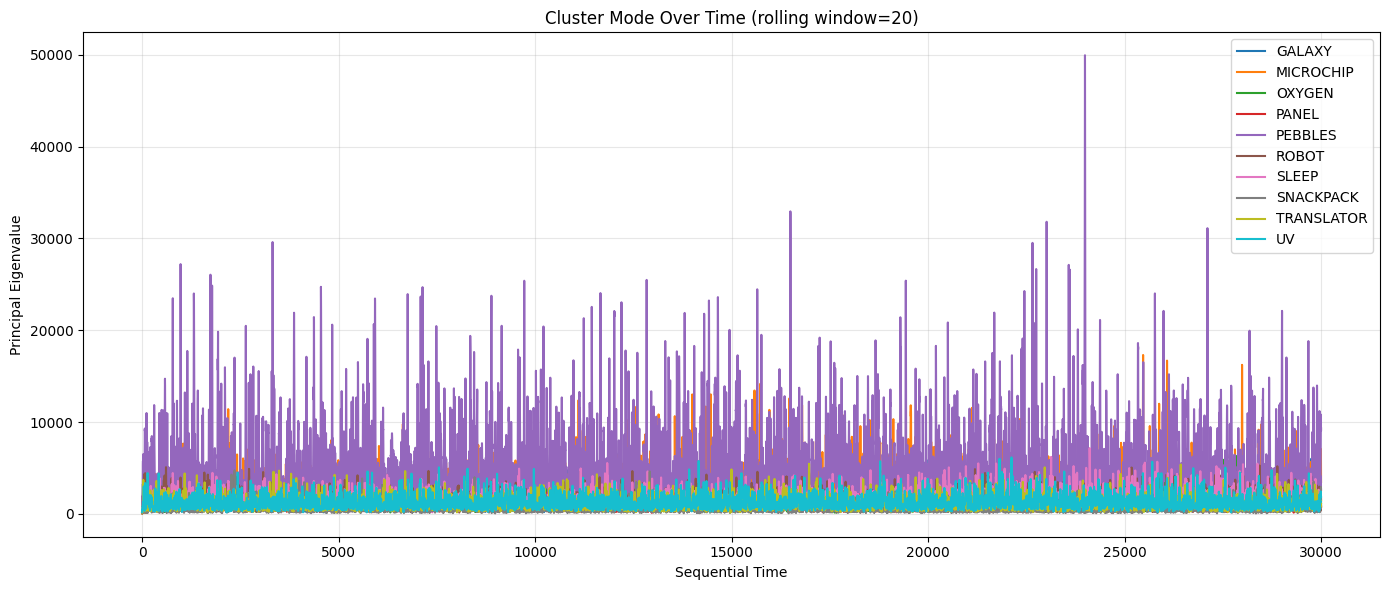

In [5]:
vis.plot_mode(mid_df)

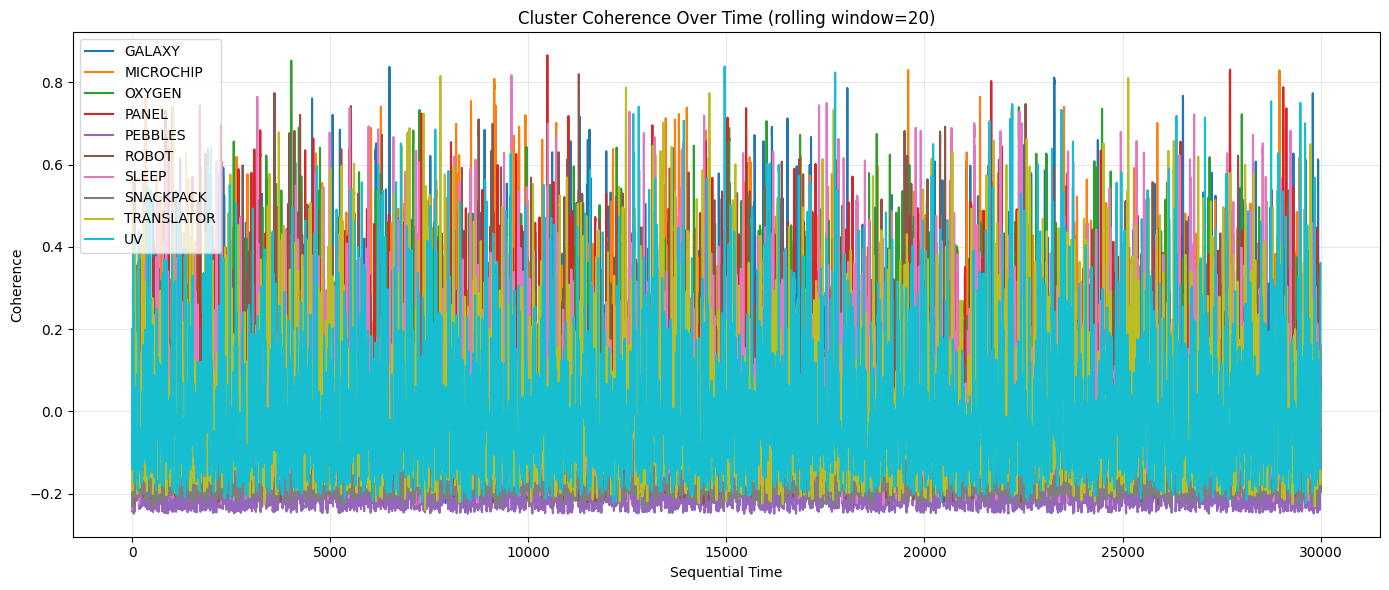

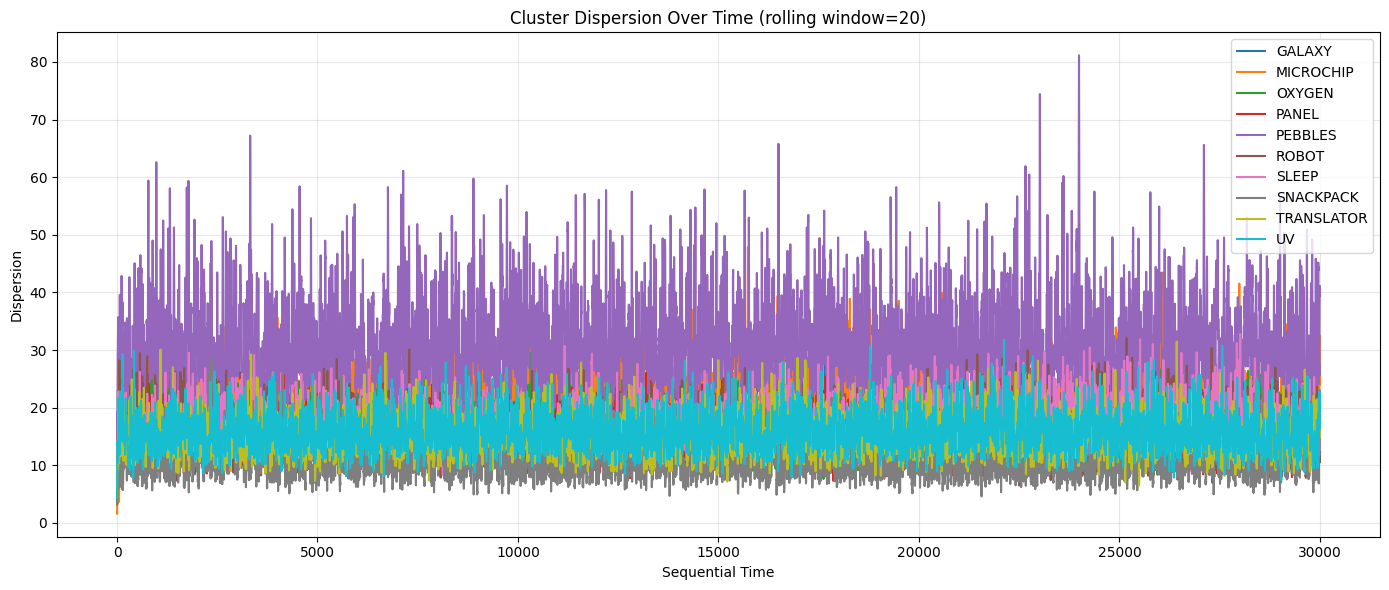

In [3]:
vis.plot_coherence(mid_df)
vis.plot_dispersion(mid_df)

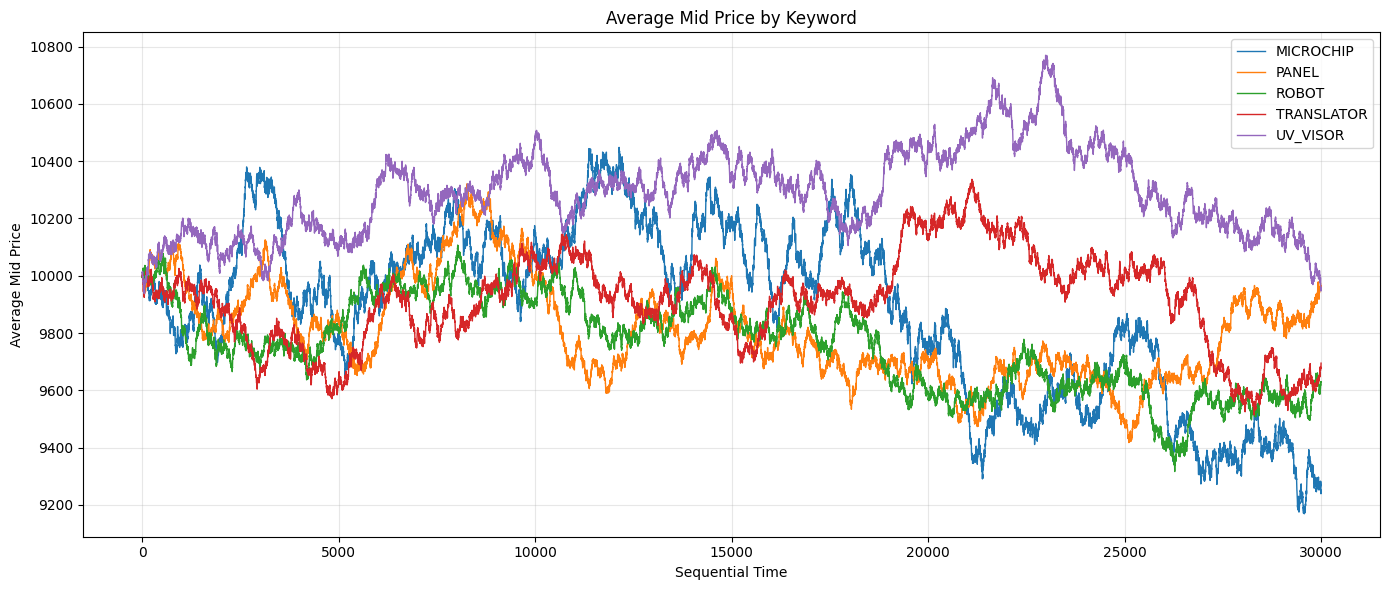

In [134]:

use = [
    #"GALAXY_SOUNDS",
    "MICROCHIP",
    #"OXYGEN_SHAKE",
    "PANEL",
    #"PEBBLES",
    "ROBOT",
    #"SLEEP_POD",
    "TRANSLATOR",
    "UV_VISOR",
]
vis.plot_all(mid_df, use)

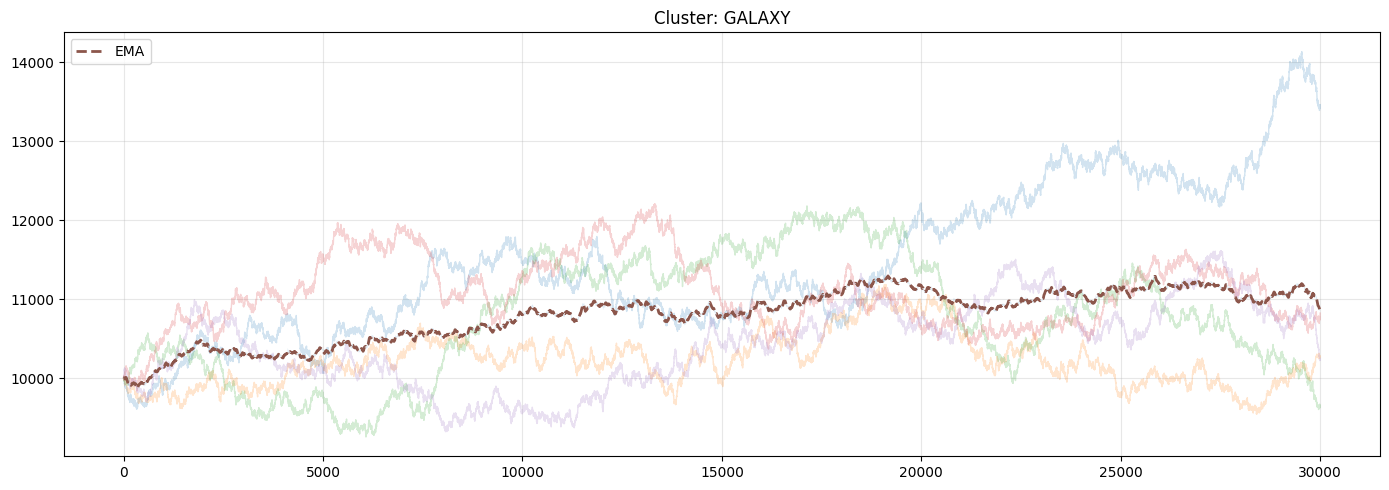

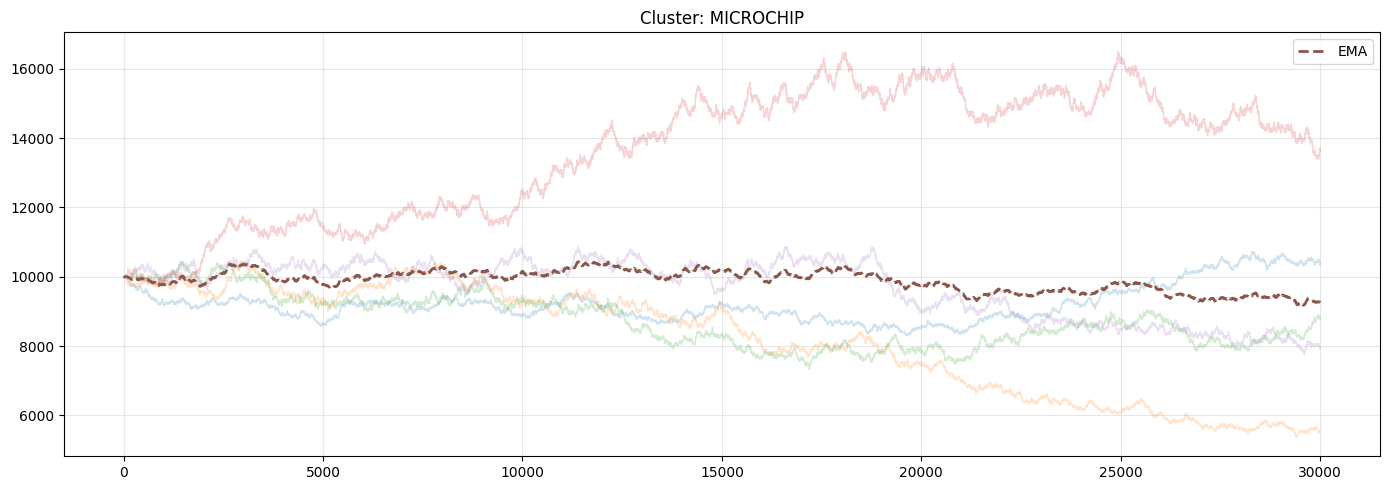

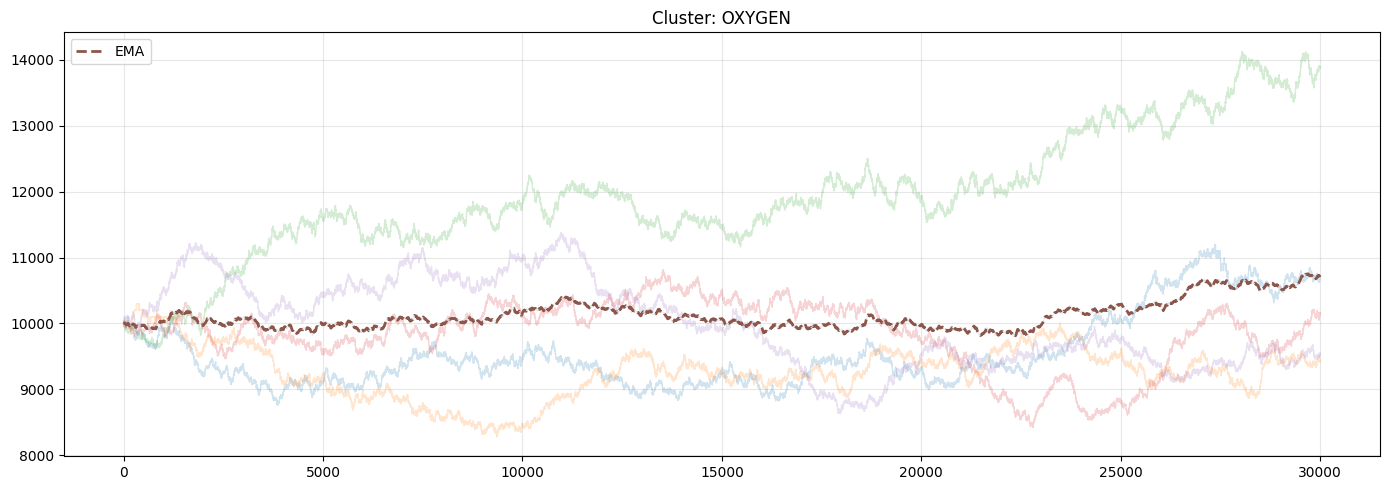

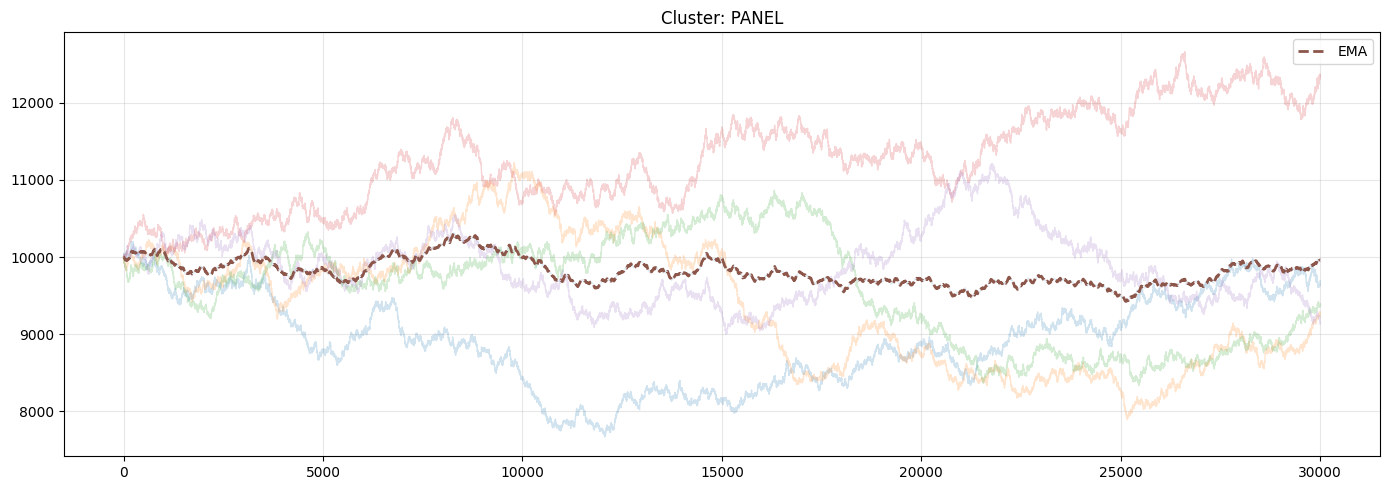

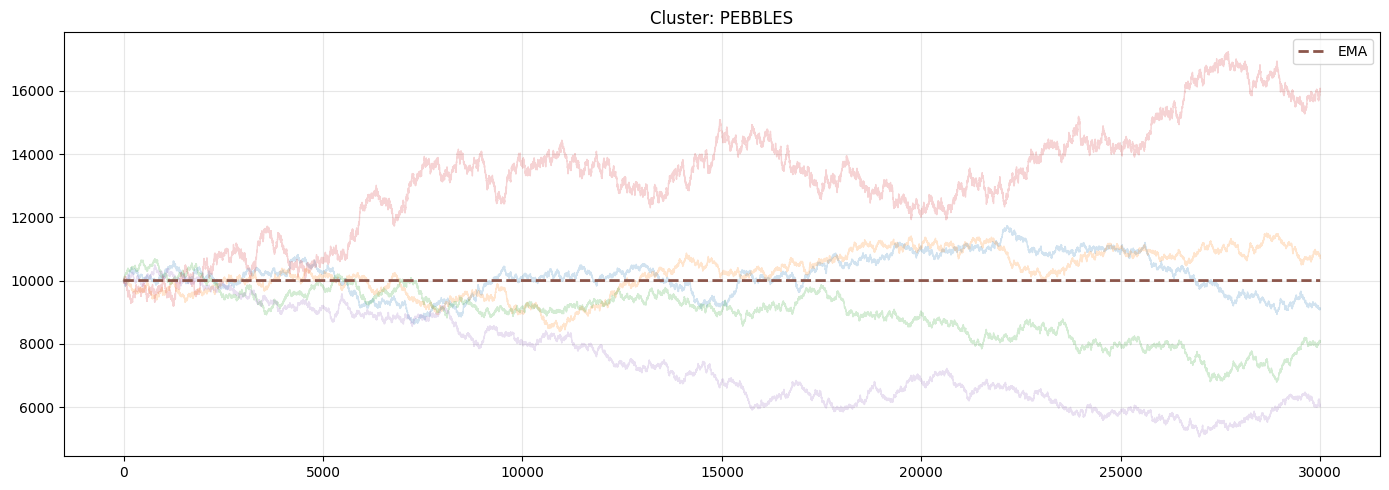

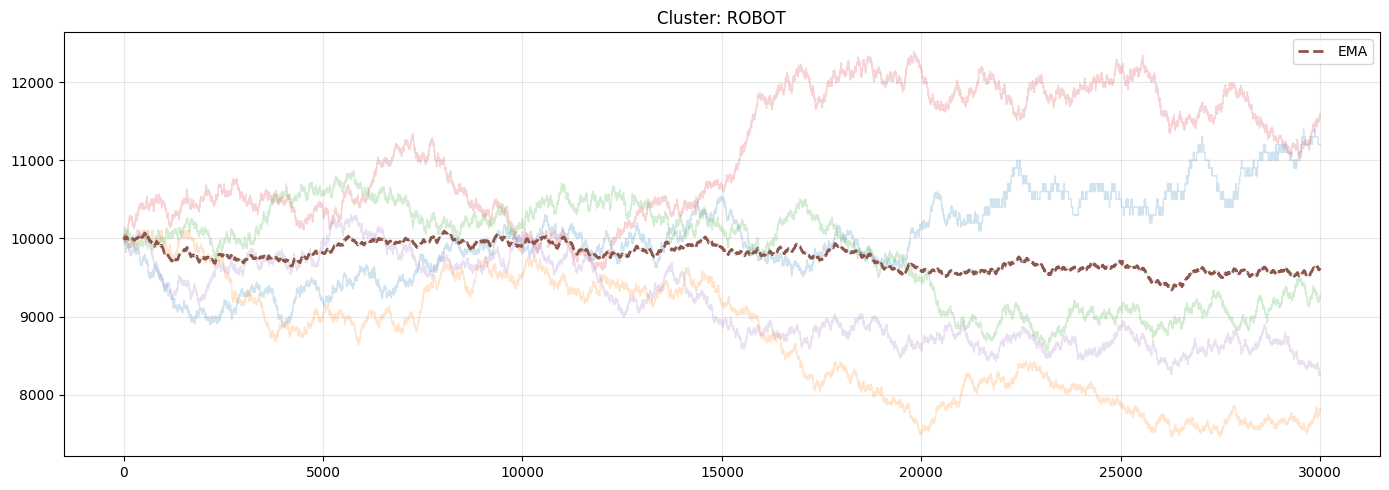

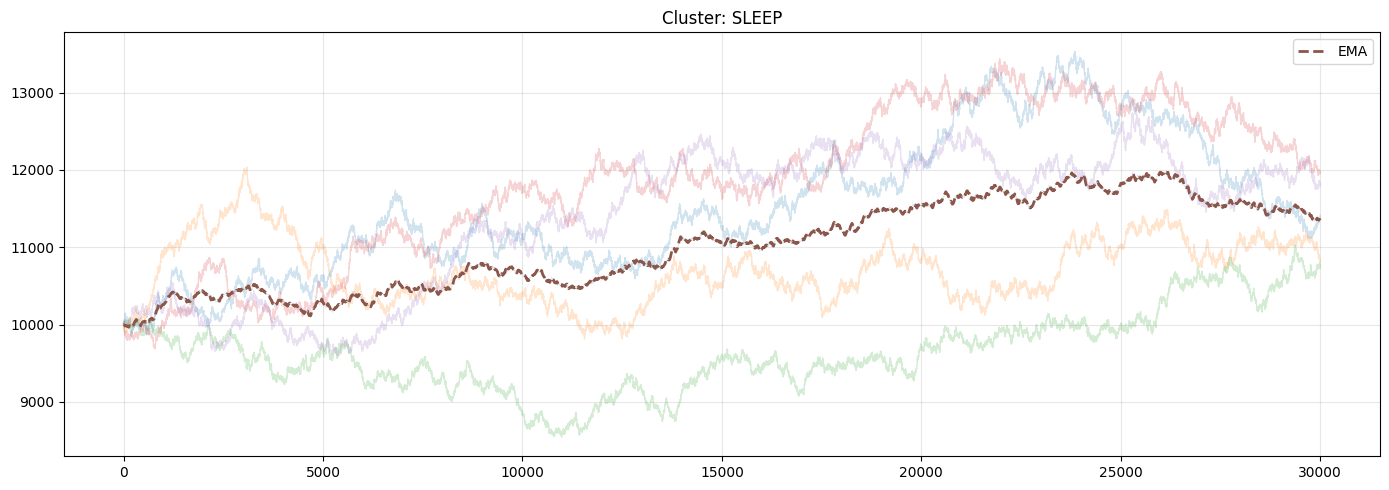

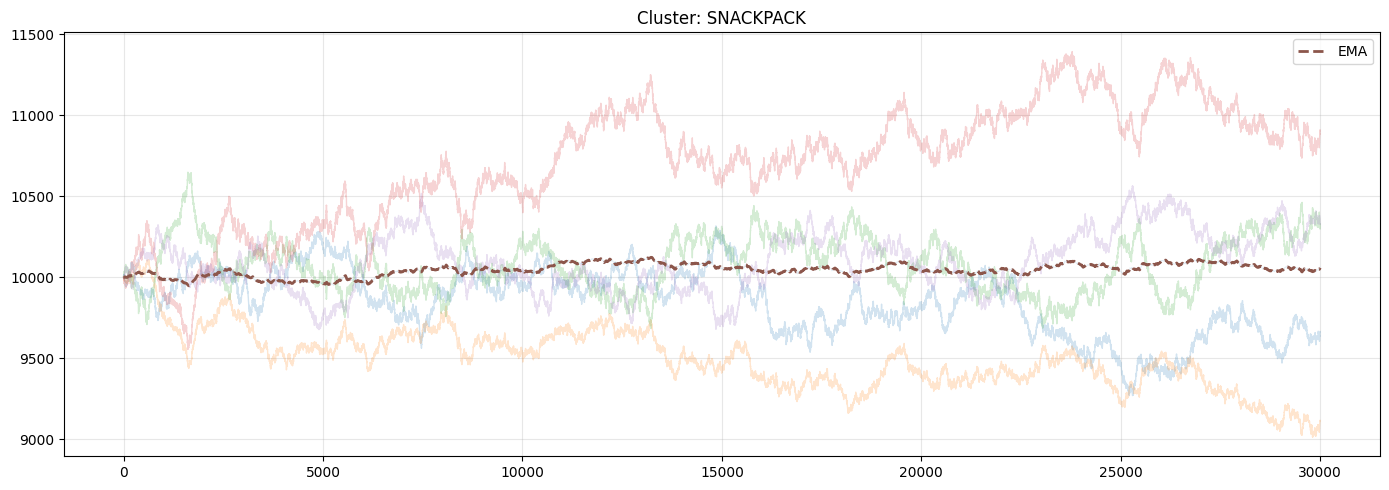

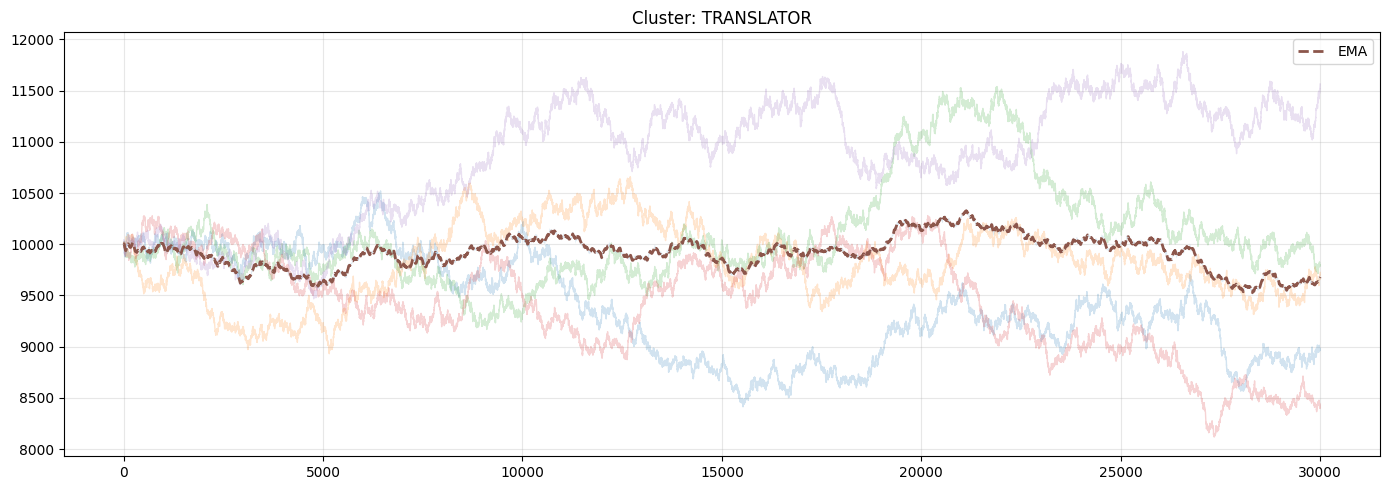

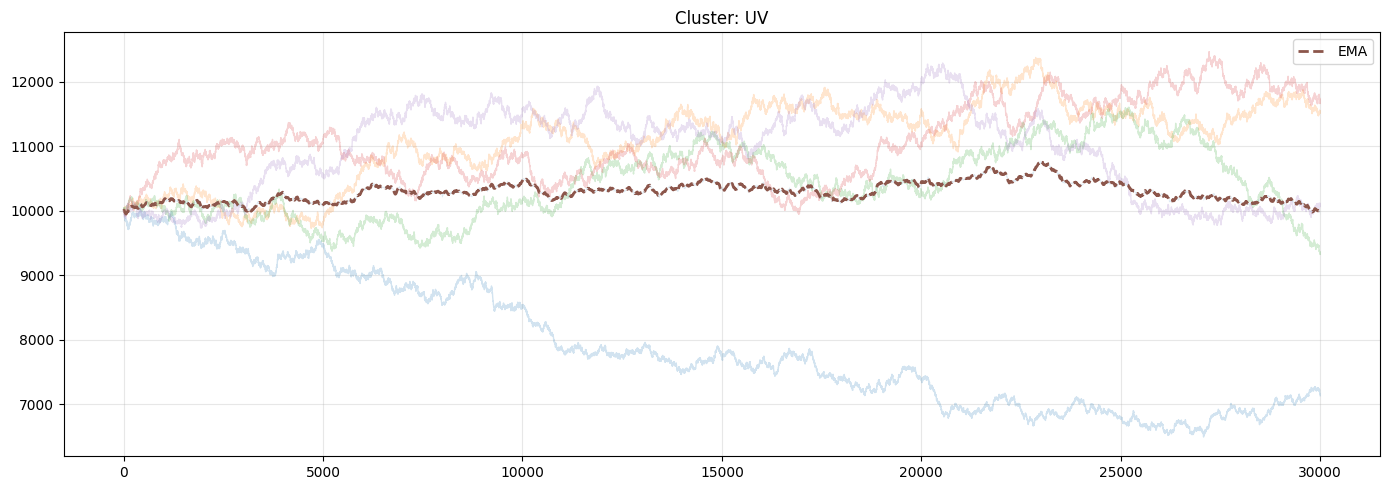

In [8]:
vis.plot_clusters(mid_df, ema_window=20, std_mult=2.0)

### Assets

- GALAXY_SOUNDS
- MICROCHIP_TRIANGLE
- OXYGEN_SHAKE
- PANEL
- PEBBLES
- ROBOT
- SLEEP_POD
- SNACKPACK
- TRANSLATOR
- UV_VISOR

In [ ]:
KEYS = [
    "GALAXY_SOUNDS",
    "MICROCHIP",
    "OXYGEN_SHAKE",
    "PANEL",
    "PEBBLES",
    "ROBOT",
    "SLEEP_POD",
    "SNACKPACK",
    "TRANSLATOR",
    "UV_VISOR",
]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

diff = (
    mid_df['SNACKPACK_CHOCOLATE']
    + mid_df['SNACKPACK_VANILLA']
    - 20_000
)/2

# remove NaNs if any
valid = diff.notna()
y = diff[valid].values

# event-time axis
t = np.arange(len(y))

# fit y = a + b t
b, a = np.polyfit(t, y, 1)

trend = b*t +a
residual = y - trend

print(a, b)

plt.figure(figsize=(12,5))
plt.plot(t, residual, label='diff - trend')
plt.axhline(0, linestyle='--')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(residual)

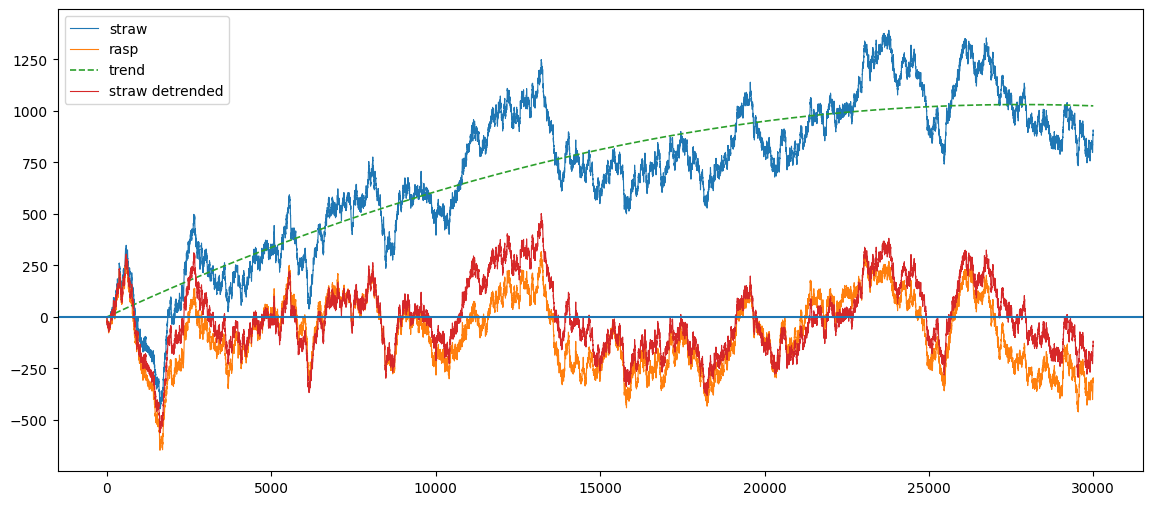

a=-0.00000133, b=0.074184


In [108]:
t = np.arange(len(mid_df))

straw = mid_df['SNACKPACK_STRAWBERRY'] - 10_000
rasp  = 10_000 - mid_df['SNACKPACK_RASPBERRY']

# quadratic no intercept: fit a*t^2 + b*t
T = np.column_stack([t**2, t])
coeffs, _, _, _ = np.linalg.lstsq(T, straw, rcond=None)
trend = T @ coeffs
detrended_straw = straw - trend

plt.figure(figsize=(14, 6))
plt.plot(t, straw,            linewidth=.8, label="straw")
plt.plot(t, rasp,             linewidth=.8, label="rasp")
plt.plot(t, trend,            linewidth=1.2, linestyle='--', label="trend")
plt.plot(t, detrended_straw,  linewidth=.8, label="straw detrended")
plt.axhline(0)
plt.legend()
plt.show()

print(f"a={coeffs[0]:.8f}, b={coeffs[1]:.6f}")

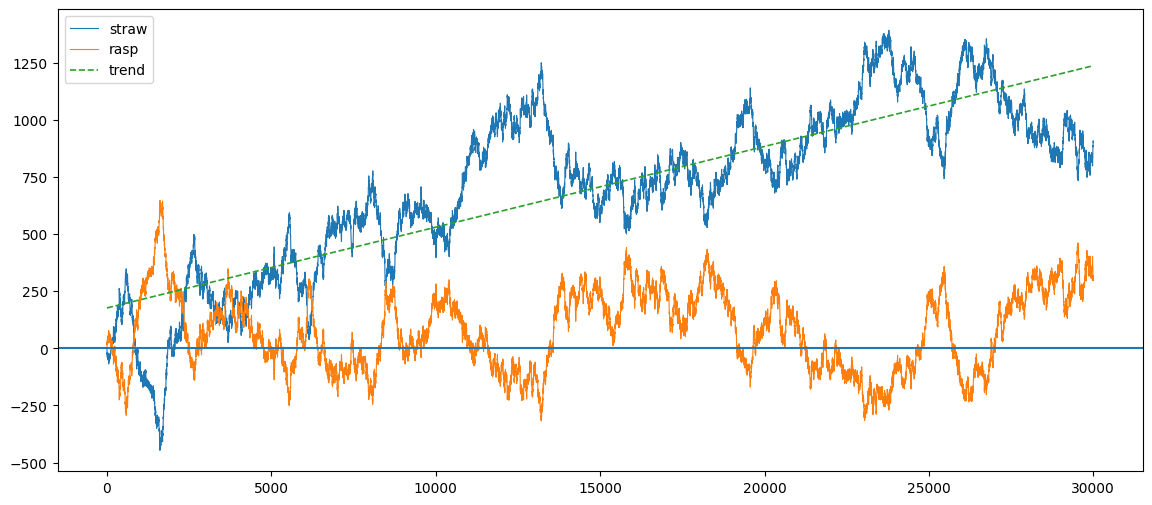

In [ ]:
t = np.arange(len(mid_df))

straw = mid_df['SNACKPACK_STRAWBERRY'] - 10_000
rasp  = mid_df['SNACKPACK_RASPBERRY'] - 10_000:

slope, intercept = np.polyfit(t, straw, deg=1)
detrended_straw = straw - (slope * t + intercept)

plt.figure(figsize=(14, 6))
plt.plot(t, straw,                      linewidth=.8, label="straw")
plt.plot(t, rasp,                       linewidth=.8, label="rasp")
plt.plot(t, slope * t + intercept,      linewidth=1.2, linestyle='--', label="trend")
plt.plot(t, detrended_straw,            linewidth=.8, label="straw detrended")
plt.axhline(0)
plt.legend()
plt.show()

print(f"slope: {slope:.6f}, intercept: {intercept:.4f}")

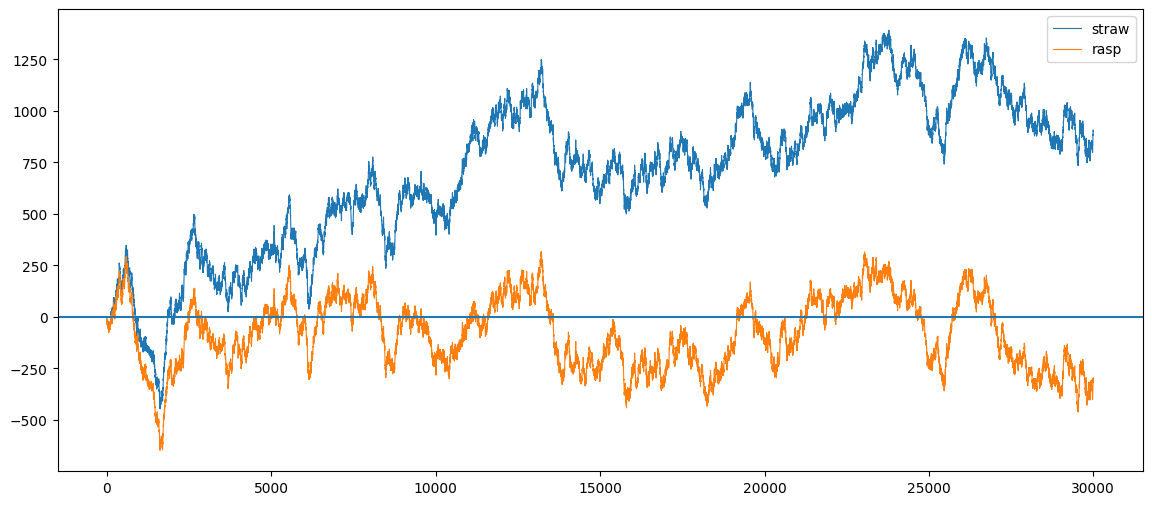

In [109]:
#vis.plot_some(mid_df, ['SNACKPACK_CHOCOLATE', 'SNACKPACK_VANILLA', 'SNACKPACK_RASPBERRY'])

plt.figure(figsize=(14, 6))
# plt.plot(np.arange(len(diff)), mid_df['SNACKPACK_CHOCOLATE'] -10_000, linewidth=.8)
# plt.plot(np.arange(len(diff)), 10_000 - mid_df['SNACKPACK_VANILLA'], linewidth=.8)
plt.plot(np.arange(len(diff)), mid_df['SNACKPACK_STRAWBERRY'] -10_000, linewidth=.8, label="straw")
plt.plot(np.arange(len(diff)), 10_000 - mid_df['SNACKPACK_RASPBERRY'], linewidth=.8, label="rasp")

plt.legend()
plt.axhline(0)
plt.show()


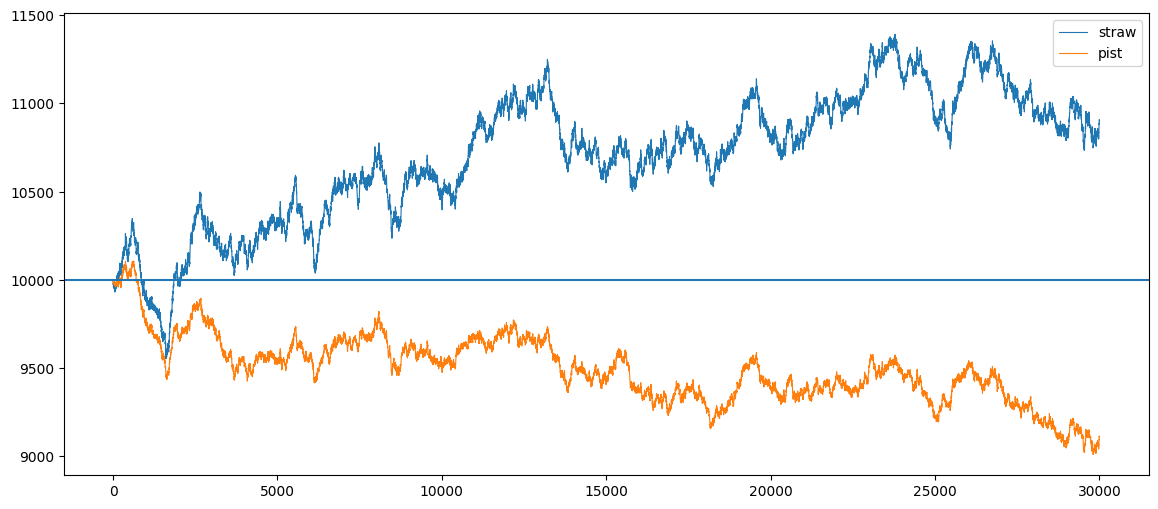

In [130]:
plt.figure(figsize=(14, 6))
# plt.plot(np.arange(len(diff)), mid_df['SNACKPACK_CHOCOLATE'], linewidth=.8, label="choc")
# plt.plot(np.arange(len(diff)),20_000 -  mid_df['SNACKPACK_VANILLA'], linewidth=.8, label="van")
plt.plot(np.arange(len(diff)), mid_df['SNACKPACK_STRAWBERRY'], linewidth=.8, label="straw")
# plt.plot(np.arange(len(diff)), mid_df['SNACKPACK_RASPBERRY'], linewidth=.8, label="rasp")
plt.plot(np.arange(len(diff)),  mid_df['SNACKPACK_PISTACHIO'], linewidth=.8, label="pist")
plt.axhline(10_000)
plt.legend()


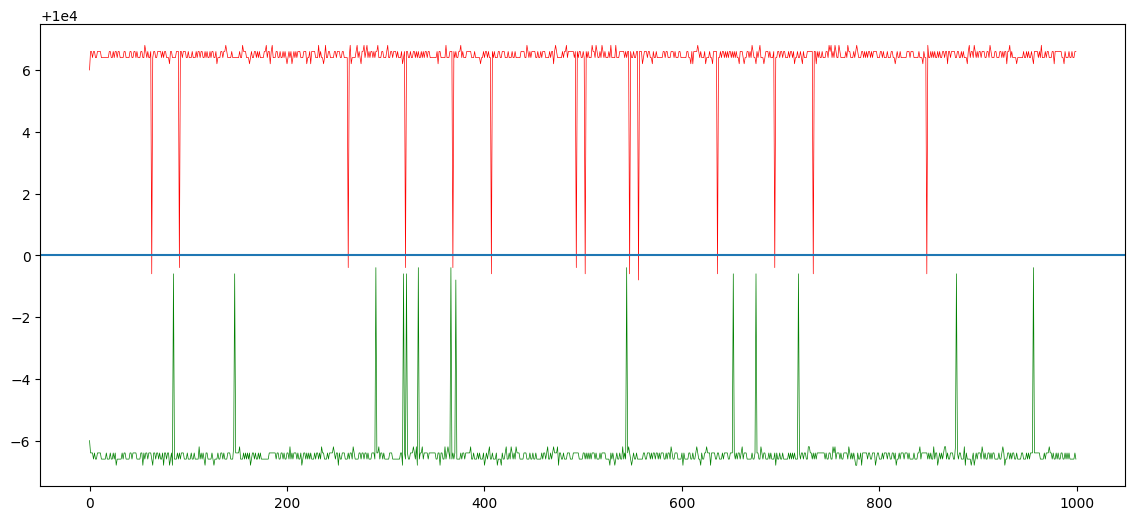

In [10]:
panel_keys =  ['PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S',
       'PEBBLES_XL', 'PEBBLES_XS']

#vis.plot_some(bid_df, panel_keys)

bid_mean = (bid_df['PEBBLES_S']+bid_df['PEBBLES_M']+bid_df['PEBBLES_L']+bid_df['PEBBLES_XL']+bid_df['PEBBLES_XS'])/5
ask_mean = (ask_df['PEBBLES_S']+ask_df['PEBBLES_M']+ask_df['PEBBLES_L']+ask_df['PEBBLES_XL']+ask_df['PEBBLES_XS'])/5
peb_mean = (mid_df['PEBBLES_S']+mid_df['PEBBLES_M']+mid_df['PEBBLES_L']+mid_df['PEBBLES_XL']+mid_df['PEBBLES_XS'])/5

begin, end = 0, 1000

bid_mean=bid_mean[begin:end]
ask_mean=ask_mean[begin:end]
peb_mean = peb_mean[begin:end]

plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(bid_mean)), bid_mean, lw = 0.5, c="g", label="bid_L1")
plt.plot(np.arange(len(ask_mean)), ask_mean, lw = 0.5, c="r", label="ask_L1")


plt.axhline(10_000)
plt.legend
plt.show()

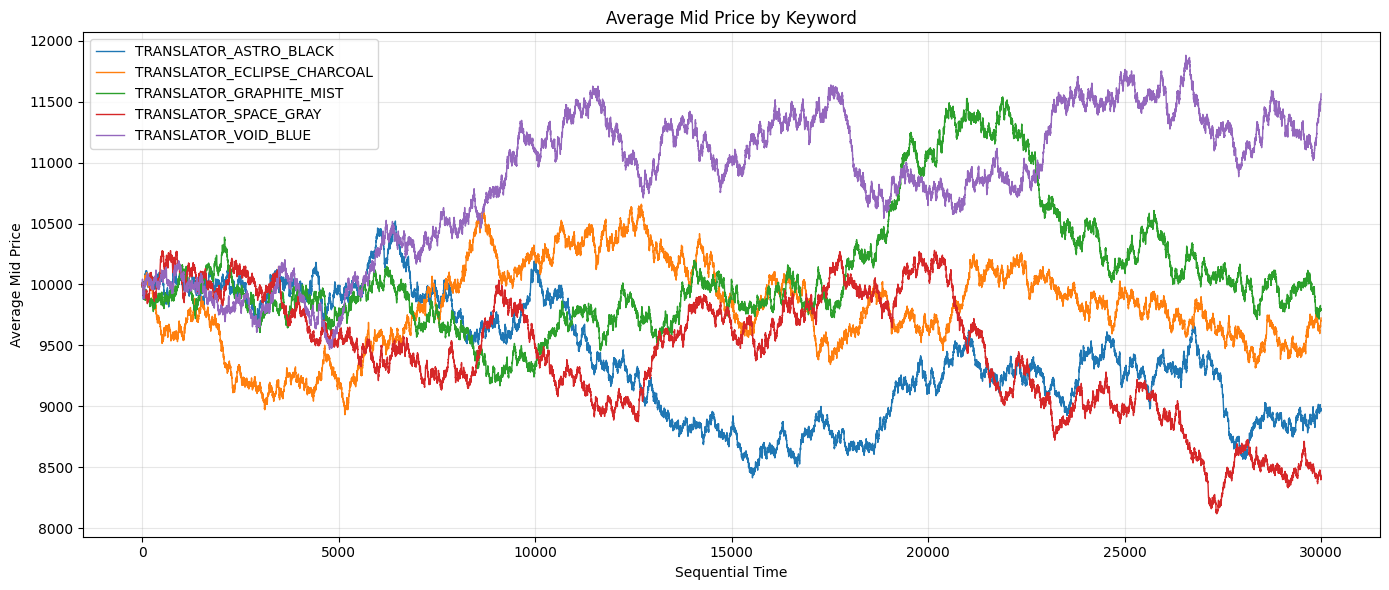

In [ ]:
trans=['TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL',
       'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_SPACE_GRAY',
       'TRANSLATOR_VOID_BLUE']
vis.plot_some(mid_df, trans)
